In [1]:
#Import Libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
#Load data
df = pd.read_csv("https://raw.githubusercontent.com/reisanar/datasets/refs/heads/master/all_billboard_summer_hits.csv")

dt = df.dtypes

display(df.head())\

#EDA and Datatypes
display(dt)

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,duration_ms,time_signature,key_mode,playlist_name,playlist_img,track_name,artist_name,album_name,album_img,year
0,0.518,0.060,A#,-14.887,major,0.0441,0.987,0.000008,0.161,0.336,...,216373.0,4,A# major,summer_hits_1958,https://mosaic.scdn.co/640/5e8c49f7a8d161c1d65...,Nel blu dipinto di blu,Domenico Modugno,Tutto Modugno (Mister Volare),https://i.scdn.co/image/5e8c49f7a8d161c1d65109...,1958.0
1,0.543,0.332,C,-11.573,major,0.0317,0.669,0.000000,0.134,0.795,...,153933.0,4,C major,summer_hits_1958,https://mosaic.scdn.co/640/5e8c49f7a8d161c1d65...,Poor Little Fool,Ricky Nelson,Ricky Nelson (Expanded Edition / Remastered),https://i.scdn.co/image/f0f2c3321ca683bdc121ba...,1958.0
2,0.541,0.676,C,-7.988,major,0.1350,0.188,0.803000,0.123,0.911,...,128360.0,4,C major,summer_hits_1958,https://mosaic.scdn.co/640/5e8c49f7a8d161c1d65...,Patricia,Pérez Prado,El Rey Del Mambo,https://i.scdn.co/image/6488d1b4d3b17500498b1e...,1958.0
3,0.408,0.397,A,-12.536,major,0.0300,0.873,0.000000,0.280,0.697,...,162773.0,4,A major,summer_hits_1958,https://mosaic.scdn.co/640/5e8c49f7a8d161c1d65...,Little Star,The Elegants,Little Star: The Best Of The Elegants,https://i.scdn.co/image/83350f7f3e709bffbd6bf4...,1958.0
4,0.554,0.189,E,-14.277,major,0.0279,0.915,0.000014,0.132,0.214,...,165293.0,3,E major,summer_hits_1958,https://mosaic.scdn.co/640/5e8c49f7a8d161c1d65...,My True Love,Jack Scott,Best Of The Rockabilly Years,https://i.scdn.co/image/9105f52cfba8e58051eced...,1958.0


danceability        float64
energy              float64
key                  object
loudness            float64
mode                 object
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
track_uri            object
duration_ms         float64
time_signature        int64
key_mode             object
playlist_name        object
playlist_img         object
track_name           object
artist_name          object
album_name           object
album_img            object
year                float64
dtype: object

In [3]:
#Let's get crafty

X = df.select_dtypes(include=['float64'])

#Pull number of fields dynamically
n_features = X.shape[1]
display(X)

#Scale?
scale = StandardScaler()
X_scaled = scale.fit_transform(X)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year
0,0.518,0.060,-14.887,0.0441,0.987000,0.000008,0.1610,0.336,127.870,216373.0,1958.0
1,0.543,0.332,-11.573,0.0317,0.669000,0.000000,0.1340,0.795,154.999,153933.0,1958.0
2,0.541,0.676,-7.988,0.1350,0.188000,0.803000,0.1230,0.911,76.231,128360.0,1958.0
3,0.408,0.397,-12.536,0.0300,0.873000,0.000000,0.2800,0.697,72.615,162773.0,1958.0
4,0.554,0.189,-14.277,0.0279,0.915000,0.000014,0.1320,0.214,136.714,165293.0,1958.0
...,...,...,...,...,...,...,...,...,...,...,...
595,0.784,0.780,-4.275,0.1020,0.049200,0.000000,0.1180,0.722,124.953,204347.0,2017.0
596,0.904,0.611,-6.842,0.0888,0.000259,0.000020,0.0976,0.400,150.020,177000.0,2017.0
597,0.726,0.769,-5.043,0.1230,0.029300,0.010100,0.1040,0.733,97.985,233902.0,2017.0
598,0.731,0.469,-7.226,0.0326,0.463000,0.000001,0.1030,0.631,98.963,165387.0,2017.0


In [4]:
#PCA
pca = PCA(n_components=n_features)
X_pca = pca.fit_transform(X_scaled)


In [5]:
#Results

pca_vals = pca.explained_variance_ratio_

print(pd.Series(pca_vals))

0     0.262065
1     0.138432
2     0.121418
3     0.096593
4     0.089848
5     0.085214
6     0.075561
7     0.050374
8     0.040726
9     0.023062
10    0.016708
dtype: float64


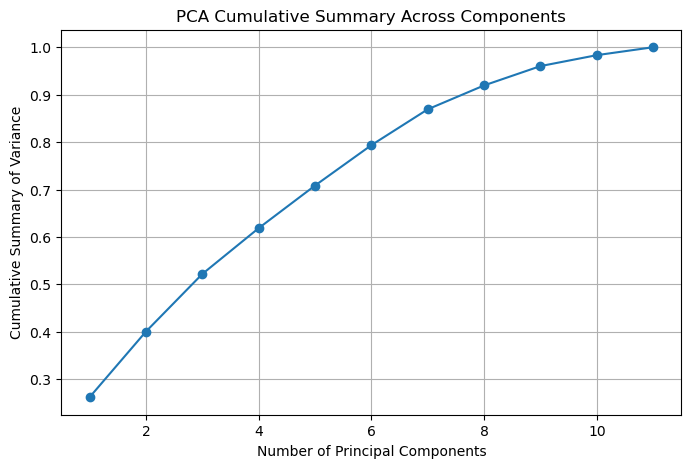

In [6]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca_vals)+1), pca_vals.cumsum(), marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Summary of Variance')
plt.title('PCA Cumulative Summary Across Components')
plt.grid(True)
plt.show()

In [7]:
#Chat GPT helped me come up with a summary table view for this.

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns
)
print(loadings)

                       PC1       PC2       PC3       PC4       PC5       PC6  \
danceability      0.305476  0.253587 -0.484774  0.140774 -0.270882  0.196800   
energy            0.458734  0.198009  0.259346 -0.231309  0.125398 -0.124553   
loudness          0.440219 -0.015807  0.303183 -0.230088  0.034371 -0.215084   
speechiness       0.209083  0.032890  0.255000  0.555028 -0.391014  0.408313   
acousticness     -0.455980  0.042865  0.119891  0.104996 -0.200569 -0.021302   
instrumentalness -0.092538  0.227372  0.116972 -0.415099  0.294125  0.758652   
liveness         -0.057141 -0.046792  0.500150 -0.255747 -0.527908  0.152206   
valence           0.164061  0.676146 -0.164993  0.038437 -0.045540 -0.035131   
tempo             0.016425  0.133208  0.419443  0.558365  0.538132  0.020784   
duration_ms       0.164333 -0.460802 -0.243653  0.029156  0.225122  0.359661   
year              0.429886 -0.390094 -0.007852  0.053340 -0.095184  0.050799   

                       PC7       PC8   